<a href="https://colab.research.google.com/github/Elvira230/NLP-Nemotron/blob/main/Sampling_%26_splitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Schema Inspection — Find the Adapted vs Synthetic Split Field
Now that we know the real field names, this notebook figures out which field
separates adapted from synthetic trajectories.

In [ ]:
!pip install datasets pandas -q
!pip install -U datasets pyarrow -q
!pip -q install huggingface_hub
!pip install sentence-transformers scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.4 MB/s eta 0:00:00


Adrian note: This is a TEST SCRIPT, which managed to pass, we can develop the rest of the dataset stuff soon, and then move to downloading the full dataset.

In [ ]:
# Code to load in the dataset
from datasets import load_dataset
from huggingface_hub import hf_hub_download, list_repo_files
import pandas as pd
import pyarrow.parquet as pq

configs = ["dataset_adapters", "skill_based_easy", "skill_based_medium", "skill_based_mixed"]
dataframes = {}

all_files = list_repo_files(
        "nvidia/Nemotron-Terminal-Corpus",
        repo_type="dataset"
        )

for config in configs:
  try:
    # Dataset adapters too large to load normally, so find shards manually instead
    if config == "dataset_adapters":
      shards = [f for f in all_files if f"{config}/" in f and f.endswith(".parquet")]

      if not shards:
        print(f"No parquet files found for {config}")
        continue
      # Get just the first shard for this config
      local_path = hf_hub_download(
                repo_id="nvidia/Nemotron-Terminal-Corpus",
                filename=shards[0],
                repo_type="dataset"
            )
      # Read first 10 rows as a record batch
      pf = pq.ParquetFile(local_path)
      first_batch = next(pf.iter_batches(batch_size=1000))
      # Convert to panda dataframe through python objects
      dataframes[config] = pd.DataFrame(first_batch.to_pylist())

    else:
      # Load in the other configs normally
      ds = load_dataset("nvidia/Nemotron-Terminal-Corpus", config)

      if "train" not in ds:
        print(f"No train split found for {config}")
        continue

      # Take first 10 rows and store them
      sample_ds = ds["train"].select(range(min(1000, len(ds["train"]))))
      dataframes[config] = sample_ds.to_pandas()

  except Exception as e:
    print(f"Failed to load {config}: {e}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_adapters/code.parquet:   0%|          | 0.00/855M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

synthetic_tasks/skill_based/easy/data_pr(…):   0%|          | 0.00/76.8M [00:00<?, ?B/s]

synthetic_tasks/skill_based/easy/data_qu(…):   0%|          | 0.00/82.1M [00:00<?, ?B/s]

...

synthetic_tasks/skill_based/mixed/debugg(…):   0%|          | 0.00/18.6M [00:00<?, ?B/s]

synthetic_tasks/skill_based/mixed/file_o(…):   0%|          | 0.00/16.3M [00:00<?, ?B/s]

synthetic_tasks/skill_based/mixed/scient(…):   0%|          | 0.00/15.1M [00:00<?, ?B/s]

synthetic_tasks/skill_based/mixed/securi(…):   0%|          | 0.00/16.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5689 [00:00<?, ? examples/s]

In [ ]:
# Test if each config is loaded properly
if "dataset_adapters" in dataframes and len(dataframes["dataset_adapters"]) > 0:
  print('dataset adapters: ', dataframes["dataset_adapters"].iloc[0])
else:
  print("dataset_adapters was not loaded successfully")

if "skill_based_easy" in dataframes and len(dataframes["skill_based_easy"]) > 0:
  print('skill base easy: ', dataframes["skill_based_easy"].iloc[0])
else:
  print("skill based easy was not loaded successfully")

if "skill_based_medium" in dataframes and len(dataframes["skill_based_medium"]) > 0:
  print('skill base medium: ', dataframes["skill_based_medium"].iloc[0])
else:
  print("skill based medium was not loaded successfully")

if "skill_based_mixed" in dataframes and len(dataframes["skill_based_mixed"]) > 0:
  print('skill base mixed: ', dataframes["skill_based_mixed"].iloc[0])
else:
  print("skill based mixed was not loaded successfully")

dataset adapters:  conversations      [{'content': 'You are an AI assistant tasked w...
agent                                                     terminus-2
model                                      deepseek-ai/DeepSeek-V3.2
model_provider                                           hosted_vllm
date                                      2025-12-15T18:16:05.385247
task                                                       task_8717
episode                                                    episode-6
run_id                          462173e4-af69-4f4a-99cf-f96fdd3c6c28
trial_name                                        task_8717__BP52K9X
enable_thinking                                                 True
source                                             OpenCodeReasoning
Name: 0, dtype: object
skill base easy:  conversations      [{'content': 'You are an AI assistant tasked w...
agent                                                     terminus-2
model                                      

## 1. Check Unique Values in Every Categorical Field
We're looking for the field that separates adapted from synthetic.

In [ ]:
from collections import Counter

fields = ["agent", "model", "model_provider", "date", "task", "trial_name", "enable_thinking"]

for config, df in dataframes.items():
    print(f"\n{'═'*50}")
    print(f"CONFIG: {config}  ({len(df)} rows)")
    print(f"Columns: {df.columns.tolist()}")
    print(f"{'═'*50}")

    for field in fields:
        if field not in df.columns:
            print(f"\n── {field} — NOT FOUND IN THIS CONFIG")
            continue
        try:
            values = Counter(df[field].astype(str).tolist())
            print(f"\n── {field} ({len(values)} unique values) ──")
            for val, count in values.most_common(10):
                preview = val[:80] + '...' if len(val) > 80 else val
                print(f"  {count:4d}x  '{preview}'")
        except Exception as e:
            print(f"\n── {field} — could not inspect: {e}")


══════════════════════════════════════════════════
CONFIG: dataset_adapters  (1000 rows)
Columns: ['conversations', 'agent', 'model', 'model_provider', 'date', 'task', 'episode', 'run_id', 'trial_name', 'enable_thinking', 'source']
══════════════════════════════════════════════════

── agent (1 unique values) ──
  1000x  'terminus-2'

── model (1 unique values) ──
  1000x  'deepseek-ai/DeepSeek-V3.2'

── model_provider (1 unique values) ──
  1000x  'hosted_vllm'

── date (1000 unique values) ──
     1x  '2025-12-15T18:16:05.385247'
     1x  '2025-12-15T18:16:05.401594'
     1x  '2025-12-15T18:16:05.417574'
     1x  '2025-12-15T18:16:05.447997'
     1x  '2025-12-15T18:16:05.478778'
     1x  '2025-12-15T18:16:05.494137'
     1x  '2025-12-15T18:16:05.509839'
     1x  '2025-12-15T18:16:05.540823'
     1x  '2025-12-15T18:16:05.556307'
     1x  '2025-12-15T18:16:05.571748'

── task (1000 unique values) ──
     1x  'task_8717'
     1x  'task_20737'
     1x  'task_8125'
     1x  'task_17751'


## 2. Inspect the `conversations` Field Structure
This is the trajectory itself — let's see what format it's in.

In [ ]:
# Config
SOURCE_FIELD = "source"
ADAPTED_LABEL = "adapted"
SYNTHETIC_LABEL = "synthetic"

# dataset_adapters is the only config with a 'source' column
ds = dataframes["dataset_adapters"]


#Check the source field exists
assert SOURCE_FIELD in ds.columns, (
    f"Field '{SOURCE_FIELD}' not found. "
    f"Available fields: {list(ds.columns.keys())}. "
    f"Update SOURCE_FIELD in the config cell."
)

#Count unique values
source_values = Counter(ds[SOURCE_FIELD])
print("=== Source field value counts ===")
for val, count in source_values.most_common():
    print(f"  '{val}': {count:,} samples ({count/len(ds)*100:.1f}%)")

# Warn if expected labels aren't found
if ADAPTED_LABEL not in source_values:
    print(f"\n DAPTED_LABEL '{ADAPTED_LABEL}' not found — update the config cell")
if SYNTHETIC_LABEL not in source_values:
    print(f"SYNTHETIC_LABEL '{SYNTHETIC_LABEL}' not found — update the config cell")

=== Source field value counts ===
  'OpenCodeReasoning': 1,000 samples (100.0%)

 DAPTED_LABEL 'adapted' not found — update the config cell
SYNTHETIC_LABEL 'synthetic' not found — update the config cell


look inside the conversations column. We could next use the "second turn" data from each entry as our data to analyze

In [ ]:
import json

#Look at one conversation from each subset
for config, df in dataframes.items():
    print(f"\n{'═'*50}")
    print(f"CONFIG: {config}")
    print(f"{'═'*50}")
    convos = df.iloc[0]["conversations"]
    print(f"Type: {type(convos)}")
    print(f"Length (# turns): {len(convos)}")
    print(f"\nFirst turn:")
    print(json.dumps(convos[0], indent=2) if isinstance(convos[0], dict) else convos[0])
    print(f"\nSecond turn:")
    print(json.dumps(convos[1], indent=2) if isinstance(convos[1], dict) else convos[1])


══════════════════════════════════════════════════
CONFIG: dataset_adapters
══════════════════════════════════════════════════
Type: <class 'list'>
Length (# turns): 14

First turn:
{
  "content": "You are an AI assistant tasked with solving command-line tasks in a Linux environment. You will be given a task description and the output from previously executed commands. Your goal is to solve the task by providing batches of shell commands.\n\nFormat your response as JSON with the following structure:\n\n{\n  \"analysis\": \"Analyze the current state based on the terminal output provided. What do you see? What has been accomplished? What still needs to be done?\",\n  \"plan\": \"Describe your plan for the next steps. What commands will you run and why? Be specific about what you expect each command to accomplish.\",\n  \"commands\": [\n    {\n      \"keystrokes\": \"ls -la\\n\",\n      \"duration\": 0.1\n    },\n    {\n      \"keystrokes\": \"cd project\\n\",\n      \"duration\": 0.1\n 

# SBERT
SBert turns pieces of text into numerical vectors called embeddings where text with similar meanings should have embeddings closer together. We're using SBert here to measure how coherent each trajectory from this dataset is. The SBert pipeline is as follow:


1.   Load trajectories
2.   Get generated assistant text
3.   Split assistant reasoning into smaller steps of text
4.   Use SBert to find embeddings for each step
5.   Compute cosine similarity between steps
6.   Average the similarities into one coherence score for each trajectory
7.   Compare adapted vs. synthetic scores statistically



### Initialize SBert Model

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

sbert = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Extract Assistant Text

In [ ]:
def get_assistant_text(row):
    # Get conversations for one trajectory
    convos = row["conversations"]

    # Normalize to list (skill_based configs return numpy arrays)
    if isinstance(convos, np.ndarray):
        convos = convos.tolist()

    #Grab ALL assistant turns, not just the second turn
    assistant_turns = [
        t.get("content", "")
        for t in convos
        if isinstance(t, dict) and t.get("role") == "assistant"
    ]

    # Join all assistant turns into one block of text
    return " ".join(assistant_turns)

### Split Assistant Respons into Steps

In [ ]:
def split_into_steps(text):
  # Split text at new lines and sentence punctuations
  steps = re.split(r'\n+|(?<=[.!?])\s+', text)
  # Remove short or empty chunks
  steps = [s.strip() for s in steps if len(s.strip()) > 20]
  return steps

### Compute Semantic Coherence

In [ ]:
def semantic_coherence(text):
    steps = split_into_steps(text)
    if len(steps) < 2:
        return np.nan
    steps = steps[:50]  # cap steps
    embeddings = sbert.encode(steps, convert_to_numpy=True, batch_size=32)  # batch encoding
    similarity = cosine_similarity(embeddings)
    adjacent_scores = [similarity[i, i + 1] for i in range(len(steps) - 1)]
    return float(np.mean(adjacent_scores))

### Apply to Dataframes

In [ ]:
from tqdm import tqdm
tqdm.pandas()

for config, df in dataframes.items():
    print(f"\nProcessing {config}...")
    df["assistant_text"] = df.apply(get_assistant_text, axis=1)
    df["sbert_coherence"] = df["assistant_text"].progress_apply(semantic_coherence)

for config, df in dataframes.items():
    print(config, df["sbert_coherence"].mean())


Processing dataset_adapters...


100%|██████████| 1000/1000 [00:37<00:00, 26.33it/s]



Processing skill_based_easy...


100%|██████████| 1000/1000 [00:41<00:00, 24.33it/s]



Processing skill_based_medium...


100%|██████████| 1000/1000 [00:29<00:00, 33.57it/s]



Processing skill_based_mixed...


100%|██████████| 1000/1000 [00:33<00:00, 30.23it/s]

dataset_adapters 0.38871365605294705
skill_based_easy 0.2910057612210512
skill_based_medium 0.3235597928315401
skill_based_mixed 0.3152791175097227


# Assign Labels and Combine Dataframes


In [ ]:
import pandas as pd

#assign labels based on config
dataframes["dataset_adapters"]["label"] = "adapted"
dataframes["skill_based_easy"]["label"] = "synthetic"
dataframes["skill_based_medium"]["label"] = "synthetic"
dataframes["skill_based_mixed"]["label"] = "synthetic"

#combine into one dataframe
combined_df = pd.concat(dataframes.values(), ignore_index=True)
print(f"Total rows: {len(combined_df)}")
print(combined_df["label"].value_counts())

Total rows: 4000
label
synthetic    3000
adapted      1000
Name: count, dtype: int64


# Visualize SBERT Coherence Scores

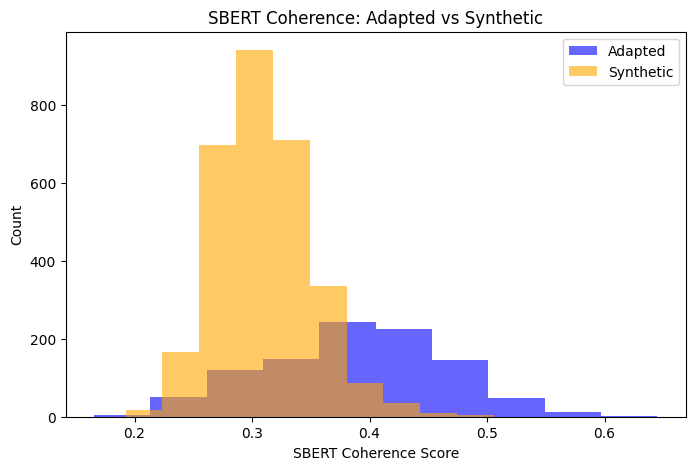

Adapted mean:   0.3887
Synthetic mean: 0.3099


In [ ]:
import matplotlib.pyplot as plt

adapted_scores = combined_df[combined_df["label"] == "adapted"]["sbert_coherence"].dropna()
synthetic_scores = combined_df[combined_df["label"] == "synthetic"]["sbert_coherence"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(adapted_scores, alpha=0.6, label="Adapted", bins=10, color="blue")
plt.hist(synthetic_scores, alpha=0.6, label="Synthetic", bins=10, color="orange")
plt.xlabel("SBERT Coherence Score")
plt.ylabel("Count")
plt.title("SBERT Coherence: Adapted vs Synthetic")
plt.legend()
plt.show()

print(f"Adapted mean:   {adapted_scores.mean():.4f}")
print(f"Synthetic mean: {synthetic_scores.mean():.4f}")

# Statistical Significance Test (Mann-Whitney U)

In [ ]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(adapted_scores, synthetic_scores, alternative="two-sided")

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT difference between adapted and synthetic (p < 0.05)")
else:
    print("Result: No significant difference detected (p >= 0.05)")

Mann-Whitney U statistic: 2426883.5000
P-value: 0.0000
Result: SIGNIFICANT difference between adapted and synthetic (p < 0.05)


# KL Divergence on SBERT Coherence  (testing, the full results will be in Statistical Tests on All Features)

In [ ]:
from scipy.stats import entropy
import numpy as np

adapted_scores = combined_df[combined_df["label"] == "adapted"]["sbert_coherence"].dropna()
synthetic_scores = combined_df[combined_df["label"] == "synthetic"]["sbert_coherence"].dropna()

#bin the scores into a histogram to get probability distributions
bins = np.linspace(0, 1, 20)
adapted_hist, _ = np.histogram(adapted_scores, bins=bins, density=True)
synthetic_hist, _ = np.histogram(synthetic_scores, bins=bins, density=True)

#Add small value to avoid division by zero
adapted_hist += 1e-10
synthetic_hist += 1e-10

# Normalize so they sum to 1
adapted_hist = adapted_hist / adapted_hist.sum()
synthetic_hist = synthetic_hist / synthetic_hist.sum()

kl_div = entropy(adapted_hist, synthetic_hist)
print(f"KL Divergence (adapted || synthetic): {kl_div:.4f}")

if kl_div < 0.1:
    print("Interpretation: Distributions are very similar")
elif kl_div < 0.5:
    print("Interpretation: Moderate difference between distributions")
else:
    print("Interpretation: Large difference between distributions")

KL Divergence (adapted || synthetic): 1.9548
Interpretation: Large difference between distributions


# Extract Structured Fields from Assistant Turns


In [ ]:
import re
import json

def extract_structured_fields(row):
    convos = row["conversations"]

    if isinstance(convos, np.ndarray):
        convos = convos.tolist()

    assistant_turns = [
        t.get("content", "")
        for t in convos
        if isinstance(t, dict) and t.get("role") == "assistant"
    ]

    all_thinking = []
    all_analysis = []
    all_plans = []
    all_commands = []

    for content in assistant_turns:
        #Extract <think> block
        think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
        if think_match:
            all_thinking.append(think_match.group(1).strip())

        #Extract JSON fields
        json_match = re.search(r"\{.*\}", content, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
                if "analysis" in parsed:
                    all_analysis.append(parsed["analysis"])
                if "plan" in parsed:
                    all_plans.append(parsed["plan"])
                if "commands" in parsed:
                    for cmd in parsed["commands"]:
                        keystroke = cmd.get("keystrokes", "").strip()
                        if keystroke:
                            all_commands.append(keystroke)
            except json.JSONDecodeError:
                pass

    return {
        "thinking_text": " ".join(all_thinking),
        "analysis_text": " ".join(all_analysis),
        "plan_text":     " ".join(all_plans),
        "commands_list": all_commands
    }

#apply to all dataframes
for config, df in dataframes.items():
    print(f"Extracting fields from {config}...")
    extracted = df.apply(extract_structured_fields, axis=1, result_type="expand")
    df["thinking_text"] = extracted["thinking_text"]
    df["analysis_text"] = extracted["analysis_text"]
    df["plan_text"]     = extracted["plan_text"]
    df["commands_list"] = extracted["commands_list"]

print("New columns added: thinking_text, analysis_text, plan_text, commands_list")

Extracting fields from dataset_adapters...
Extracting fields from skill_based_easy...
Extracting fields from skill_based_medium...
Extracting fields from skill_based_mixed...
New columns added: thinking_text, analysis_text, plan_text, commands_list


# Compute Linguistic Features

In [ ]:
from collections import Counter
import re

def compute_ttr(text):
    #Tokenize by splitting on whitespace and puntuation
    tokens = re.findall(r'\b\w+\b', text.lower())
    if len(tokens) == 0:
        return np.nan
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens)

def compute_instruction_length(row):
    #total word count of analysis + plan combined
    combined = row["analysis_text"] + " " + row["plan_text"]
    tokens = re.findall(r'\b\w+\b', combined)
    return len(tokens)

def compute_reasoning_steps(text):
    #count numbered steps or newlines in thinking block
    steps = [s.strip() for s in re.split(r'\n+', text) if len(s.strip()) > 20]
    return len(steps)

def compute_self_corrections(text):
    # Count how often agent second guesses itself
    patterns = r'\b(wait|actually|however|reconsider|let me re|mistake|incorrect|wrong|re-think|but wait)\b'
    matches = re.findall(patterns, text.lower())
    return len(matches)

def compute_command_diversity(commands_list):
    if not commands_list or len(commands_list) == 0:
        return 0
    #Extract the base command (first word) from each keystroke
    base_commands = []
    for cmd in commands_list:
        first_word = cmd.strip().split()[0] if cmd.strip() else ""
        if first_word:
            base_commands.append(first_word)
    unique_commands = set(base_commands)
    return len(unique_commands)

#apply all features to every dataframe
for config, df in dataframes.items():
    print(f"Computing features for {config}...")
    df["ttr"]                = df["thinking_text"].apply(compute_ttr)
    df["instruction_length"] = df.apply(compute_instruction_length, axis=1)
    df["reasoning_steps"]    = df["thinking_text"].apply(compute_reasoning_steps)
    df["self_corrections"]   = df["thinking_text"].apply(compute_self_corrections)
    df["command_diversity"]  = df["commands_list"].apply(compute_command_diversity)

print("\nFeature summary:")
for config, df in dataframes.items():
    print(f"\n{config}:")
    print(df[["ttr", "instruction_length", "reasoning_steps", "self_corrections", "command_diversity"]].mean())

Computing features for dataset_adapters...
Computing features for skill_based_easy...
Computing features for skill_based_medium...
Computing features for skill_based_mixed...

Feature summary:

dataset_adapters:
ttr                     0.13706
instruction_length    764.09500
reasoning_steps       106.65800
self_corrections       49.87000
command_diversity       4.01200
dtype: float64

skill_based_easy:
ttr                     0.230231
instruction_length    683.792000
reasoning_steps        68.083000
self_corrections       14.249000
command_diversity       6.737000
dtype: float64

skill_based_medium:
ttr                     0.202178
instruction_length    768.942000
reasoning_steps        84.360000
self_corrections       17.581000
command_diversity       8.187000
dtype: float64

skill_based_mixed:
ttr                     0.217105
instruction_length    644.049000
reasoning_steps        76.672000
self_corrections       14.345000
command_diversity       7.479000
dtype: float64


# Statistical Tests on All Features

In [ ]:
from scipy.stats import mannwhitneyu
from scipy.stats import entropy
import numpy as np

#rebuild combined_df with new features
combined_df = pd.concat(dataframes.values(), ignore_index=True)

features = ["ttr", "instruction_length", "reasoning_steps", "self_corrections", "command_diversity", "sbert_coherence"]

adapted = combined_df[combined_df["label"] == "adapted"]
synthetic = combined_df[combined_df["label"] == "synthetic"]

print(f"{'Feature':<25} {'Adapted Mean':>15} {'Synthetic Mean':>15} {'P-Value':>10} {'KL Divergence':>15} {'Significant?':>12}")
print("=" * 95)

for feature in features:
    adapted_scores = adapted[feature].dropna()
    synthetic_scores = synthetic[feature].dropna()

    #MannWhitney U
    stat, p_value = mannwhitneyu(adapted_scores, synthetic_scores, alternative="two-sided")

    #KL divergence
    bins = np.linspace(
        min(adapted_scores.min(), synthetic_scores.min()),
        max(adapted_scores.max(), synthetic_scores.max()),
        20
    )
    adapted_hist, _   = np.histogram(adapted_scores, bins=bins, density=True)
    synthetic_hist, _ = np.histogram(synthetic_scores, bins=bins, density=True)
    adapted_hist   += 1e-10
    synthetic_hist += 1e-10
    adapted_hist   = adapted_hist / adapted_hist.sum()
    synthetic_hist = synthetic_hist / synthetic_hist.sum()
    kl_div = entropy(adapted_hist, synthetic_hist)

    significant = "YES" if p_value < 0.05 else "NO"
                                                              #for p value can change the e on 10.4 to f if we just want to round it to 4 decimals
    print(f"{feature:<25} {adapted_scores.mean():>15.4f} {synthetic_scores.mean():>15.4f} {p_value:>10.4e} {kl_div:>15.4f} {significant:>12}")

Feature                      Adapted Mean  Synthetic Mean    P-Value   KL Divergence Significant?
ttr                                0.1371          0.2165 2.3498e-214          1.7350          YES
instruction_length               764.0950        698.9277 3.7387e-25          0.5544          YES
reasoning_steps                  106.6580         76.3717 4.2466e-39          0.3560          YES
self_corrections                  49.8700         15.3917 4.5310e-190          2.4734          YES
command_diversity                  4.0120          7.4677 0.0000e+00          2.2136          YES
sbert_coherence                    0.3887          0.3099 8.4581e-189          2.1903          YES


# Visualize All Feature Distributions

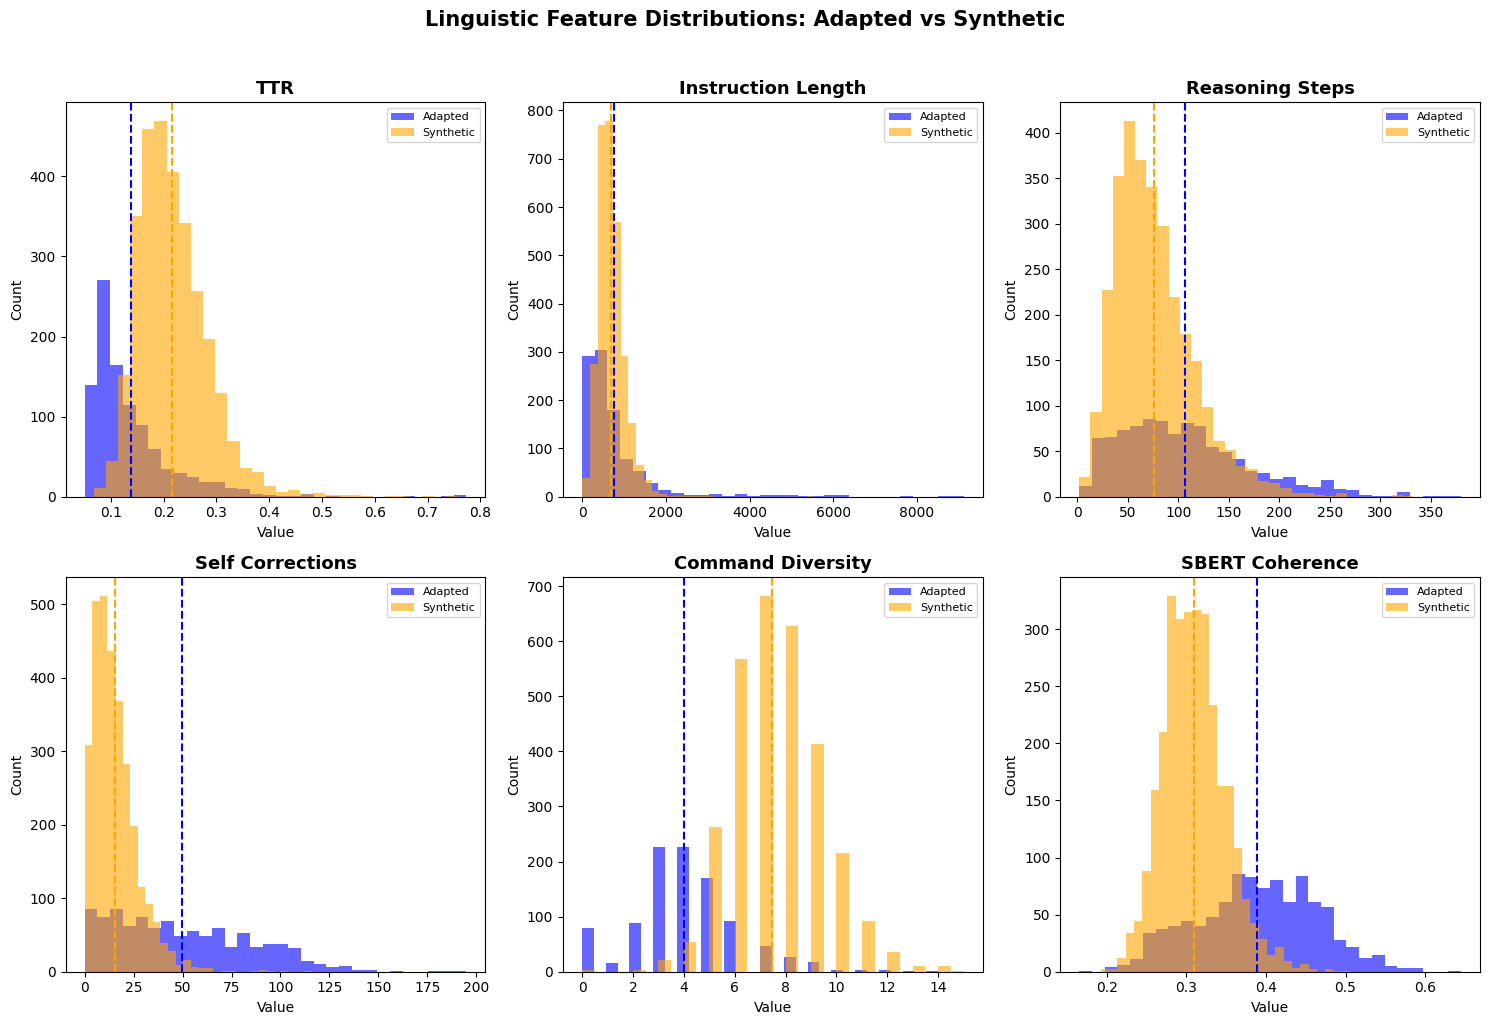

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = ["ttr", "instruction_length", "reasoning_steps", "self_corrections", "command_diversity", "sbert_coherence"]
feature_labels = ["TTR", "Instruction Length", "Reasoning Steps", "Self Corrections", "Command Diversity", "SBERT Coherence"]

adapted = combined_df[combined_df["label"] == "adapted"]
synthetic = combined_df[combined_df["label"] == "synthetic"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axes[i]

    adapted_scores = adapted[feature].dropna()
    synthetic_scores = synthetic[feature].dropna()

    ax.hist(adapted_scores, alpha=0.6, label="Adapted", color="blue", bins=30)
    ax.hist(synthetic_scores, alpha=0.6, label="Synthetic", color="orange", bins=30)

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    ax.axvline(adapted_scores.mean(), color="blue", linestyle="dashed", linewidth=1.5)
    ax.axvline(synthetic_scores.mean(), color="orange", linestyle="dashed", linewidth=1.5)
    ax.legend(fontsize=8)

plt.suptitle("Linguistic Feature Distributions: Adapted vs Synthetic", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Classifier Baselines (Majority & Bag-of-Words)

## 1. Prepare Balanced Classification Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Keep only the text and label needed for classification
clf_df = combined_df[["assistant_text", "label"]].dropna().copy()
clf_df["assistant_text"] = clf_df["assistant_text"].astype(str)

# Remove empty or extremely short examples
clf_df = clf_df[clf_df["assistant_text"].str.len() > 20]

# Balance adapted and synthetic so accuracy is meaningful
adapted_df = clf_df[clf_df["label"] == "adapted"]
synthetic_df = clf_df[clf_df["label"] == "synthetic"]

n = min(len(adapted_df), len(synthetic_df), 1000)

adapted_sample = adapted_df.sample(n=n, random_state=42)
synthetic_sample = synthetic_df.sample(n=n, random_state=42)

balanced_df = pd.concat([adapted_sample, synthetic_sample], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Convert labels to numbers
label_map = {
    "adapted": 0,
    "synthetic": 1
}

balanced_df["y"] = balanced_df["label"].map(label_map)

print("Balanced dataset:")
print(balanced_df["label"].value_counts())

Balanced dataset:
label
synthetic    1000
adapted      1000
Name: count, dtype: int64


## 2. train/dev/test/ split

In [ ]:
X = balanced_df["assistant_text"]
y = balanced_df["y"]

# 70% train, 15% dev, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Dev size:   {len(X_dev)}")
print(f"Test size:  {len(X_test)}")

Train size: 1400
Dev size:   300
Test size:  300


## 3. Majority Baseline

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

majority_clf = DummyClassifier(strategy="most_frequent")
majority_clf.fit(X_train, y_train)

majority_preds = majority_clf.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    majority_preds,
    average="binary",
    zero_division=0
)

majority_acc = accuracy_score(y_test, majority_preds)

majority_precision = precision
majority_recall = recall
majority_f1 = f1

print("Majority Class Baseline")
print(f"Accuracy:  {majority_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print()
print(classification_report(
    y_test,
    majority_preds,
    target_names=["adapted", "synthetic"],
    zero_division=0
))

Majority Class Baseline
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1:        0.0000

              precision    recall  f1-score   support

     adapted       0.50      1.00      0.67       150
   synthetic       0.00      0.00      0.00       150

    accuracy                           0.50       300
   macro avg       0.25      0.50      0.33       300
weighted avg       0.25      0.50      0.33       300



## 4. Bag-of-Words baseline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

bow_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

bow_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### 4.1 Evaluate Bag-of-Words on dev and test

In [ ]:
def evaluate_classifier(name, model, X_eval, y_eval):
    preds = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_eval, probs)
    else:
        auc = None

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_eval,
        preds,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(y_eval, preds)

    print(name)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")

    if auc is not None:
        print(f"ROC-AUC:   {auc:.4f}")

    print()
    print(classification_report(
        y_eval,
        preds,
        target_names=["adapted", "synthetic"],
        zero_division=0
    ))

    return {
        "model": name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    }

bow_dev_results = evaluate_classifier(
    "Bag-of-Words / TF-IDF Baseline - Dev",
    bow_clf,
    X_dev,
    y_dev
)

bow_test_results = evaluate_classifier(
    "Bag-of-Words / TF-IDF Baseline - Test",
    bow_clf,
    X_test,
    y_test
)

Bag-of-Words / TF-IDF Baseline - Dev
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000
ROC-AUC:   1.0000

              precision    recall  f1-score   support

     adapted       1.00      1.00      1.00       150
   synthetic       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Bag-of-Words / TF-IDF Baseline - Test
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000
ROC-AUC:   1.0000

              precision    recall  f1-score   support

     adapted       1.00      1.00      1.00       150
   synthetic       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Adding this to check why the suspicious 100% accuracy

In [ ]:
import numpy as np

vectorizer = bow_clf.named_steps["tfidf"]
classifier = bow_clf.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_[0]

top_synthetic_idx = np.argsort(coefs)[-30:]
top_adapted_idx = np.argsort(coefs)[:30]

print("Top words/phrases associated with SYNTHETIC:")
for word, weight in zip(feature_names[top_synthetic_idx][::-1], coefs[top_synthetic_idx][::-1]):
    print(f"{word:<30} {weight:.4f}")

print("\nTop words/phrases associated with ADAPTED:")
for word, weight in zip(feature_names[top_adapted_idx], coefs[top_adapted_idx]):
    print(f"{word:<30} {weight:.4f}")

## check for duplicates

print("Total rows:", len(balanced_df))
print("Unique assistant_text rows:", balanced_df["assistant_text"].nunique())

duplicates = balanced_df[balanced_df.duplicated("assistant_text", keep=False)]
print("Duplicate rows:", len(duplicates))

Top words/phrases associated with SYNTHETIC:
csv                            3.3505
json                           3.2610
timestamp                      2.2218
events                         1.7428
missing                        1.5272
jsonl                          1.5231
data                           1.3837
category                       1.3789
readings                       1.3503
the script                     1.3376
date                           1.3312
00                             1.2782
summary                        1.2380
datetime                       1.1406
row                            1.0938
interpolation                  1.0459
sensor_id                      1.0120
user_id                        0.9907
event                          0.9730
valid                          0.9539
records                        0.9522
sensor                         0.9520
timestamps                     0.9473
the csv                        0.9203
sessions                       0.9063
sessi

Luis here, the Bag-of-Words baseline achieved perfect accuracy, but feature inspection showed that the model relied heavily on domain-specific terms such as csv, json, and timestamp for synthetic samples, and solution, dp, edges, and algorithm for adapted samples. This suggests that the two sampled subsets are highly lexically separable, though the separation may partly reflect task-domain differences rather than only abstract linguistic style.

So I will add another version that ignores domain/task words, and uses function words only so that we can focus on style/structure. Let's see if the accuracy drops

### 4.2 Bag-of-Words for only function words


In [ ]:
FUNCTION_WORDS = {
    "the", "a", "an", "and", "or", "but", "if", "then", "else",
    "when", "while", "for", "to", "of", "in", "on", "with", "by",
    "from", "as", "at", "is", "are", "was", "were", "be", "been",
    "being", "it", "this", "that", "these", "those", "we", "i",
    "you", "they", "he", "she", "will", "would", "can", "could",
    "should", "may", "might", "must", "not", "so", "because",
    "therefore", "however", "also", "first", "next", "finally",
    "now", "let", "need", "want", "check"
}

def keep_function_words_only(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    kept = [tok for tok in tokens if tok in FUNCTION_WORDS]
    return " ".join(kept)

balanced_df["function_text"] = balanced_df["assistant_text"].apply(keep_function_words_only)

X_func = balanced_df["function_text"]
y = balanced_df["y"]

X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_func,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_dev_f, X_test_f, y_dev_f, y_test_f = train_test_split(
    X_temp_f,
    y_temp_f,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_f
)

func_bow_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

func_bow_clf.fit(X_train_f, y_train_f)

func_bow_test_results = evaluate_classifier(
    "Function-Words-Only Bag-of-Words Baseline - Test",
    func_bow_clf,
    X_test_f,
    y_test_f
)

Function-Words-Only Bag-of-Words Baseline - Test
Accuracy:  0.9800
Precision: 0.9615
Recall:    1.0000
F1:        0.9804
ROC-AUC:   0.9997

              precision    recall  f1-score   support

     adapted       1.00      0.96      0.98       150
   synthetic       0.96      1.00      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



Accuracy just dropped by a little, suggesting that adapted and synthetic trajectories still show distinguishable stylistic/template patterns.

Bag-of-Words is probably too strong and too topic-sensitive. I think it might be good to also add another baseline approach. Kenny already computed features: instruction_length, reasoning_steps, self_corrections, command_diversity, sbert_coherence. I am thinking of adding a simple linguistic regression model on those features.



## 5 Logistic Regression on linguistic features

In [ ]:
# ================================
# Feature-Based Logistic Regression Baseline
# ================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report
import pandas as pd
import numpy as np

feature_cols = [
    "ttr",
    "instruction_length",
    "reasoning_steps",
    "self_corrections",
    "command_diversity",
    "sbert_coherence"
]

feature_df = combined_df[feature_cols + ["label"]].dropna().copy()

# Balance adapted and synthetic
adapted_df = feature_df[feature_df["label"] == "adapted"]
synthetic_df = feature_df[feature_df["label"] == "synthetic"]

n = min(len(adapted_df), len(synthetic_df), 1000)

balanced_feature_df = pd.concat([
    adapted_df.sample(n=n, random_state=42),
    synthetic_df.sample(n=n, random_state=42)
], ignore_index=True)

balanced_feature_df = balanced_feature_df.sample(frac=1, random_state=42).reset_index(drop=True)

balanced_feature_df["y"] = balanced_feature_df["label"].map({
    "adapted": 0,
    "synthetic": 1
})

X = balanced_feature_df[feature_cols]
y = balanced_feature_df["y"]

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

feature_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

feature_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
def evaluate_feature_classifier(name, model, X_eval, y_eval):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_eval,
        preds,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(y_eval, preds)
    auc = roc_auc_score(y_eval, probs)

    print(name)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print()
    print(classification_report(
        y_eval,
        preds,
        target_names=["adapted", "synthetic"],
        zero_division=0
    ))

    return {
        "model": name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    }

feature_dev_results = evaluate_feature_classifier(
    "Feature-Based Logistic Regression - Dev",
    feature_clf,
    X_dev,
    y_dev
)

feature_test_results = evaluate_feature_classifier(
    "Feature-Based Logistic Regression - Test",
    feature_clf,
    X_test,
    y_test
)

Feature-Based Logistic Regression - Dev
Accuracy:  0.8333
Precision: 0.8012
Recall:    0.8867
F1:        0.8418
ROC-AUC:   0.9340

              precision    recall  f1-score   support

     adapted       0.87      0.78      0.82       150
   synthetic       0.80      0.89      0.84       150

    accuracy                           0.83       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.83      0.83       300

Feature-Based Logistic Regression - Test
Accuracy:  0.9100
Precision: 0.8917
Recall:    0.9333
F1:        0.9121
ROC-AUC:   0.9660

              precision    recall  f1-score   support

     adapted       0.93      0.89      0.91       150
   synthetic       0.89      0.93      0.91       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



## 6. Results table

In [ ]:
# Make sure majority metrics were saved before other evaluations overwrite precision/recall/f1
majority_results = {
    "model": "Majority Class Baseline",
    "accuracy": majority_acc,
    "precision": majority_precision if "majority_precision" in globals() else 0.0,
    "recall": majority_recall if "majority_recall" in globals() else 0.0,
    "f1": majority_f1 if "majority_f1" in globals() else 0.0,
    "roc_auc": None
}

# Collect every model result that exists so far
all_results = [majority_results]

possible_results = [
    "bow_dev_results",
    "bow_test_results",
    "clean_bow_test_results",
    "func_bow_test_results",
    "thinking_bow_test_results",
    "feature_dev_results",
    "feature_test_results",
]

for result_name in possible_results:
    if result_name in globals():
        all_results.append(globals()[result_name])

baseline_results = pd.DataFrame(all_results)

# Optional: order columns nicely
baseline_results = baseline_results[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

baseline_results

,model,accuracy,precision,recall,f1,roc_auc
0,Majority Class Baseline,0.500000,0.000000,0.000000,0.000000,NaN
1,Bag-of-Words / TF-IDF Baseline - Dev,1.000000,1.000000,1.000000,1.000000,1.000000
2,Bag-of-Words / TF-IDF Baseline - Test,1.000000,1.000000,1.000000,1.000000,1.000000
3,Function-Words-Only Bag-of-Words Baseline - Test,0.980000,0.961538,1.000000,0.980392,0.999689
4,Feature-Based Logistic Regression - Dev,0.833333,0.801205,0.886667,0.841772,0.934044
5,Feature-Based Logistic Regression - Test,0.910000,0.891720,0.933333,0.912052,0.965956
